# 2025-11-21 Runge-Kutta

## Last time

* Implicit methods
* Stiffness (informal)

## Today
* $A$- and $L$-stability
* Advection-diffusion
* Exploring stiffness
* Runge-Kutta methods

In [2]:
using Plots
default(linewidth=3)
using LinearAlgebra
using SparseArrays

function plot_stability(Rz, method; xlim=(-3, 2), ylim=(-1.5, 1.5))
    x = xlim[1]:.02:xlim[2]
    y = ylim[1]:.02:ylim[2]
    plot(title="Stability: $method", aspect_ratio=:equal, xlim=xlim, ylim=ylim)
    heatmap!(x, y, (x, y) -> abs(Rz(x + 1im*y)), c=:bwr, clims=(0, 2))
    contour!(x, y, (x, y) -> abs(Rz(x + 1im*y)), color=:black, linewidth=2, levels=[1.])
    plot!(x->0, color=:black, linewidth=1, label=:none)
    plot!([0, 0], [ylim...], color=:black, linewidth=1, label=:none)
end

function ode_theta_linear(A, u0; forcing=zero, tfinal=1, h=0.1, theta=.5)
    u = copy(u0)
    t = 0.
    thist = [t]
    uhist = [u0]
    while t < tfinal
        tnext = min(t+h, tfinal)
        h = tnext - t
        rhs = (I + h*(1-theta)*A) * u .+ h*forcing(t+h*theta)
        u = (I - h*theta*A) \ rhs
        t = tnext
        push!(thist, t)
        push!(uhist, u)
    end
    thist, hcat(uhist...)
end

Rz_theta(z, theta) = (1 + (1 - theta)*z) / (1 - theta*z)

function advdiff_matrix(n; kappa=1, wind=1, upwind=0.)
    dx = 2 / n
    rows = [1]
    cols = [1]
    vals = [0.]
    wrap(j) = (j + n - 1) % n + 1
    for i in 1:n
        append!(rows, [i, i, i])
        append!(cols, wrap.(i-1:i+1))
        diffuse = [-1, 2, -1] * kappa / dx^2
        advect_upwind = [-1, 1, 0] * wind / dx
        advect_center = [-1, 0, 1] * wind / 2dx
        stencil = -diffuse - upwind * advect_upwind - (1 - upwind) * advect_center
        append!(vals, stencil)
    end
    sparse(rows, cols, vals)
end
advdiff_matrix(5, kappa=.1)

5×5 SparseMatrixCSC{Float64, Int64} with 15 stored entries:
 -1.25   -0.625    ⋅       ⋅      1.875
  1.875  -1.25   -0.625    ⋅       ⋅ 
   ⋅      1.875  -1.25   -0.625    ⋅ 
   ⋅       ⋅      1.875  -1.25   -0.625
 -0.625    ⋅       ⋅      1.875  -1.25

# Stability classes and the $\theta$ method


## Definition: $A$-stability
A method is $A$-stable if the stability region
$$ \{ z : |R(z)| \le 1 \} $$
contains the entire left half plane $$ \Re[z] \le 0 .$$
This means that the method can take arbitrarily large time steps without becoming unstable (diverging) for any problem that is indeed physically stable.

## Definition: $L$-stability
A time integrator with stability function $R(z)$ is $L$-stable if
$$ \lim_{z\to\infty} R(z) = 0 .$$
For the $\theta$ method, we have
$$ \lim_{z\to \infty} \frac{1 + (1-\theta)z}{1 - \theta z} = \frac{1-\theta}{\theta} . $$
Evidently only $\theta=1$ is $L$-stable.

# Heat equation as linear ODE

* How do different $\theta \in [0, 1]$ compare in terms of stability?
* Are there artifacts even when the solution is stable?

In [18]:
using SparseArrays

function heat_matrix(n)
    dx = 2 / n
    rows = [1]
    cols = [1]
    vals = [0.]
    wrap(j) = (j + n - 1) % n + 1
    for i in 1:n
        append!(rows, [i, i, i])
        append!(cols, wrap.([i-1, i, i+1]))
        append!(vals, [1, -2, 1] ./ dx^2)
    end
    sparse(rows, cols, vals)
end
heat_matrix(5)

5×5 SparseMatrixCSC{Float64, Int64} with 15 stored entries:
 -12.5     6.25     ⋅       ⋅      6.25
   6.25  -12.5     6.25     ⋅       ⋅ 
    ⋅      6.25  -12.5     6.25     ⋅ 
    ⋅       ⋅      6.25  -12.5     6.25
   6.25     ⋅       ⋅      6.25  -12.5

  1.459778 seconds (5.35 M allocations: 276.450 MiB, 3.10% gc time, 99.93% compilation time)


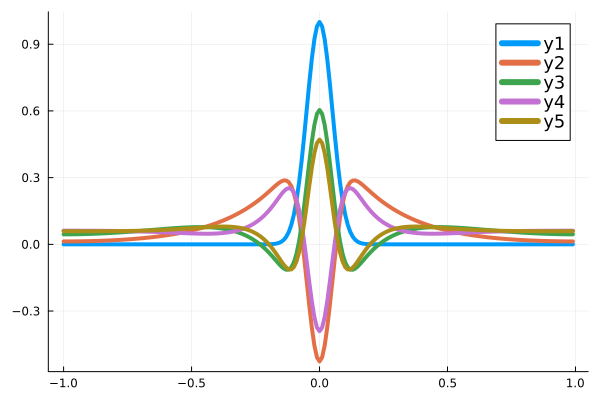

In [19]:
n = 200
A = heat_matrix(n)
x = LinRange(-1, 1, n+1)[1:end-1]
u0 = exp.(-200 * x .^ 2)
@time thist, uhist = ode_theta_linear(A, u0, h=.1, theta=.5, tfinal=1);
nsteps = size(uhist, 2)
plot(x, uhist[:, 1:5])

# Advection as a linear ODE

In [20]:
function advect_matrix(n; upwind=false)
    dx = 2 / n
    rows = [1]
    cols = [1]
    vals = [0.]
    wrap(j) = (j + n - 1) % n + 1
    for i in 1:n
        append!(rows, [i, i])
        if upwind
            append!(cols, wrap.([i-1, i]))
            append!(vals, [1., -1] ./ dx)
        else
            append!(cols, wrap.([i-1, i+1]))
            append!(vals, [1., -1] ./ 2dx)
        end
    end
    sparse(rows, cols, vals)
end
advect_matrix(5)

5×5 SparseMatrixCSC{Float64, Int64} with 11 stored entries:
  0.0   -1.25    ⋅      ⋅     1.25
  1.25    ⋅    -1.25    ⋅      ⋅ 
   ⋅     1.25    ⋅    -1.25    ⋅ 
   ⋅      ⋅     1.25    ⋅    -1.25
 -1.25    ⋅      ⋅     1.25    ⋅ 

  0.063425 seconds (99.89 k allocations: 7.127 MiB, 98.51% compilation time)


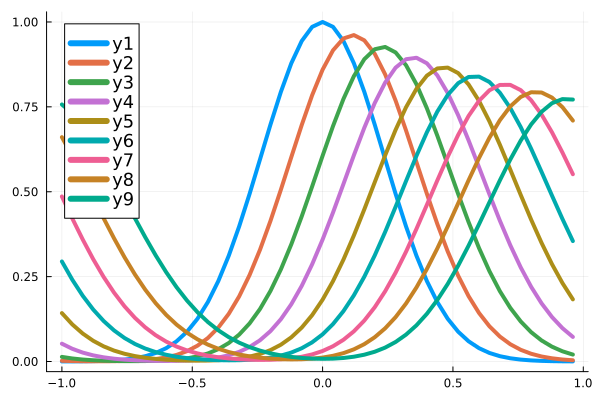

In [21]:
n = 50
A = advect_matrix(n, upwind=false)
x = LinRange(-1, 1, n+1)[1:end-1]
u0 = exp.(-9 * x .^ 2)
@time thist, uhist = ode_theta_linear(A, u0, h=.04, theta=1, tfinal=1.);
nsteps = size(uhist, 2)
plot(x, uhist[:, 1:(nsteps÷8):end])

# Spectrum of operators

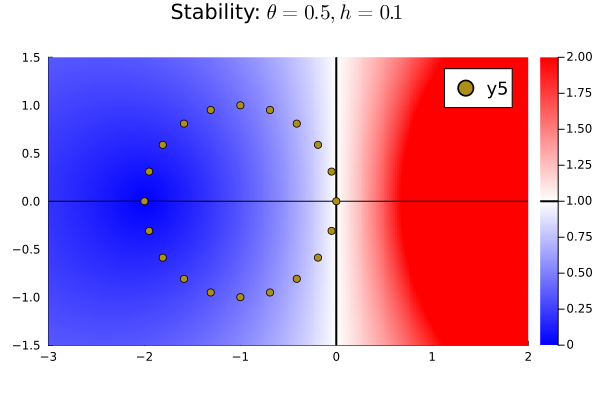

In [22]:
theta=.5
h = .1
plot_stability(z -> Rz_theta(z, theta), "\$\\theta=$theta, h=$h\$")
ev = eigvals(Matrix(h*advect_matrix(20, upwind=true)))
scatter!(real(ev), imag(ev))

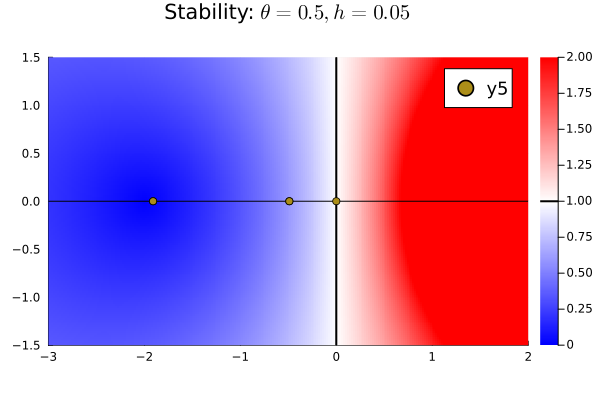

In [23]:
theta=.5
h = .2 / 4
plot_stability(z -> Rz_theta(z, theta), "\$\\theta=$theta, h=$h\$")
ev = eigvals(Matrix(h*heat_matrix(20)))
scatter!(real(ev), imag(ev))

# Stiffness

> Stiff equations are problems for which explicit methods don't work. (Hairer and Wanner, 2002)

* "stiff" dates to Curtiss and Hirschfelder (1952)

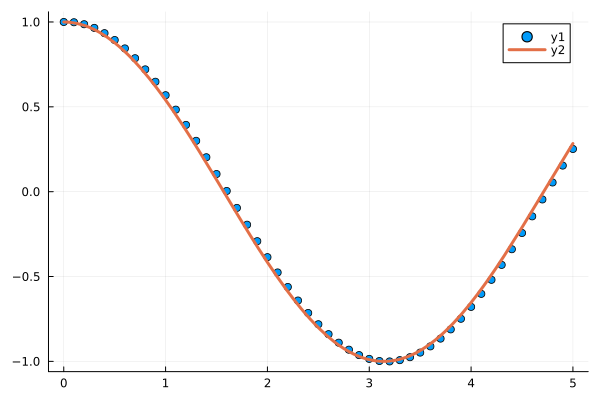

In [3]:
k = 30
thist, uhist = ode_theta_linear(-k, [1.0], forcing=t -> k*cos(t), tfinal=5, h=.1, theta=0.5)
scatter(thist, uhist[1,:])
plot!(cos)

In [4]:
function mms_error(h; theta=.5, k=10)
    u0 = [.2]
    thist, uhist = ode_theta_linear(-k, u0, forcing=t -> k*cos(t), tfinal=3, h=h, theta=theta)
    T = thist[end]
    u_exact = (u0 .- k^2/(k^2+1)) * exp(-k*T) .+ k*(sin(T) + k*cos(T))/(k^2 + 1)
    uhist[1,end] .- u_exact
end

mms_error (generic function with 1 method)

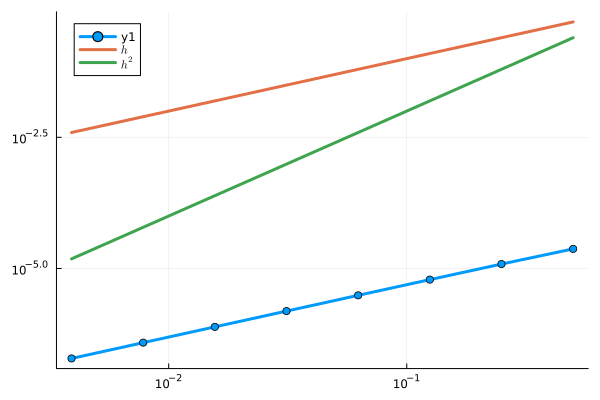

In [5]:
hs = .5 .^ (1:8)
errors = mms_error.(hs, theta=1, k=10000)
plot(hs, norm.(errors), marker=:circle, xscale=:log10, yscale=:log10)
plot!(hs, hs, label="\$h\$", legend=:topleft)
plot!(hs, hs.^2, label="\$h^2\$")


## Discuss: is advection-diffusion stiff?

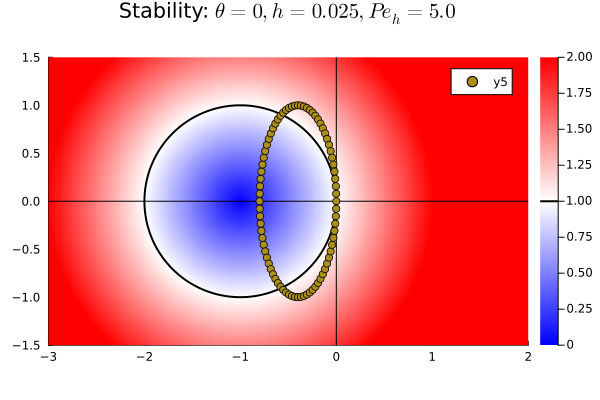

In [6]:
theta=0
n = 80
dx = 2 / n
kappa = .005
lambda_min = -4 * kappa / dx^2
cfl = 1
h = min(-2 / lambda_min, cfl * dx)

plot_stability(z -> Rz_theta(z, theta),
    "\$\\theta=$theta, h=$h, Pe_h = $(h/kappa)\$")
ev = eigvals(Matrix(h*advdiff_matrix(n, kappa=kappa, wind=1)))
scatter!(real(ev), imag(ev))

# Cost scaling

* Spatial discretization with error $O((\Delta x)^p)$
* Time discretization with error $O((\Delta t)^q)$

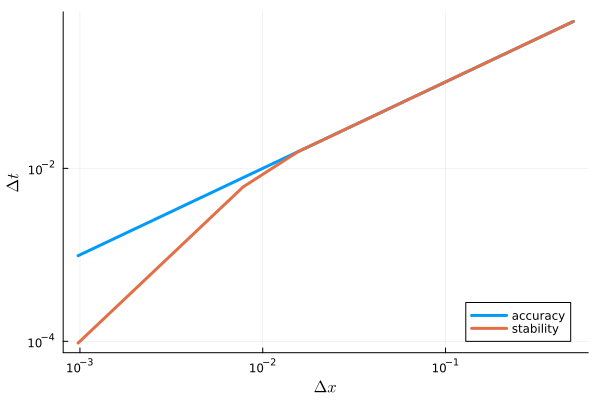

In [7]:
p = 2   # spatial order of accuracy
q = 2   # temporal order of accuracy
Pe = 100 # Peclet number with wind=1

dt_accuracy(dx) = dx .^ (p/q)
dt_stability(dx) = min(dx, Pe * dx ^ 2)

n = 2 .^ (1:10); dx = 1 ./ n
plot(dx, [dt_accuracy.(dx) dt_stability.(dx)],
    label=["accuracy" "stability"], 
    xscale=:log10, yscale=:log10, legend=:bottomright,
    xlabel="\$\\Delta x\$", ylabel="\$\\Delta t\$")

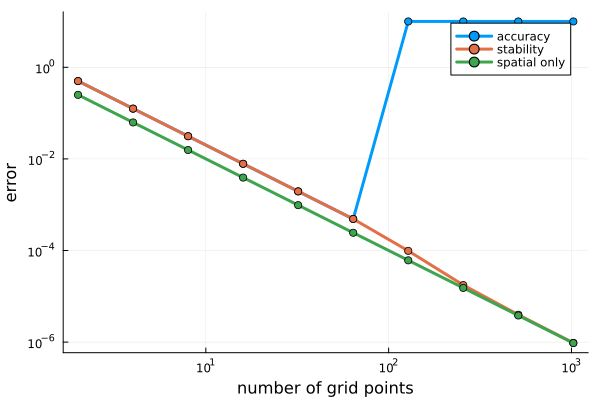

In [8]:
function error((dx, dt))
    dt <= dt_stability(dx) ? dx ^ p + dt ^ q : 10
end
plot(n, [error.(zip(dx, dt_accuracy.(dx))) error.(zip(dx, dt_stability.(dx))) dx.^p],
    label=["accuracy" "stability" "spatial only"],
    marker=:circle, xscale=:log10, yscale=:log10,
    xlabel="number of grid points", ylabel="error")

# Work-precision (error vs cost)

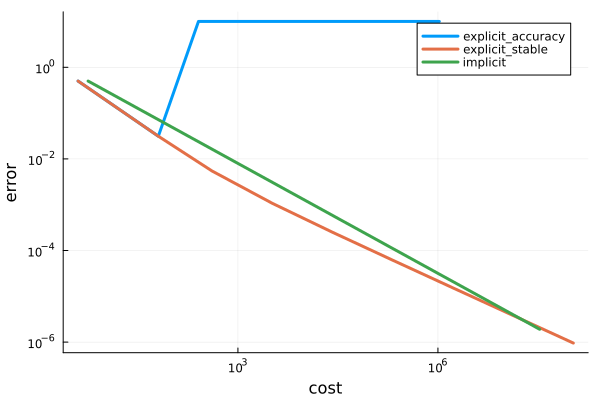

In [9]:
p = 2
q = 2
Pe = 10
dt = [dt_accuracy.(dx) dt_stability.(dx) dt_accuracy.(dx)]
c = [n./dt[:,1] n./dt[:,2] (n.^1.5)./dt[:,3]] # O(n^1.5 solve cost)
e = [error.(zip(dx, dt[:,1])) error.(zip(dx, dt[:,2])) dx.^p+dt[:,3].^q]
plot(c, e, xscale=:log10, yscale=:log10,
  label=["explicit_accuracy" "explicit_stable" "implicit"], xlabel="cost", ylabel="error")

* Stability can be an extreme demand for explicit methods
* Order of accuracy matters; usually balance spatial order $p$ and temporal order $q$
* Actual cost depends heavily on solver efficiency: O(n) vs O(n^2)
* "Constants matter"

# Runge-Kutta methods

The methods we have considered thus far can all be expressed as Runge-Kutta methods, which are expressed in terms of $s$ "stage" equations (possibly coupled) and a completion formula.  For the ODE

$$ \dot u = f(t, u) $$

the Runge-Kutta method is

$$\begin{split}
Y_i = u(t) + h \sum_j a_{ij} f(t+c_j h, Y_j) \\
u(t+h) = u(t) + h \sum_j b_j f(t+c_j h, Y_j)
\end{split}$$
where $c$ is a vector of *abscissa*, $A$ is a table of coefficients, and $b$ is a vector of completion weights.

These coefficients are typically expressed in a Butcher Table
$$ \left[ \begin{array}{c|c} c & A \\ \hline & b^T \end{array} \right] = \left[ \begin{array}{c|cc}
c_0 & a_{00} & a_{01} \\
c_1 & a_{10} & a_{11} \\
\hline
& b_0 & b_1
\end{array} \right] . $$
We will see that, for consistency, the abscissa $c$ are always the row sums of $A$ and that $\sum_i b_i = 1$.

If the matrix $A$ is strictly lower triangular, then the method is **explicit** (does not require solving equations). 

# Past methods as Runge-Kutta

* Forward Euler
$$ \left[ \begin{array}{c|cc}
0 & 0 \\
\hline
& 1
\end{array} \right] ,$$
* Backward Euler
$$ \left[ \begin{array}{c|c}
1 & 1 \\
\hline
& 1
\end{array} \right] ,$$
* Midpoint
$$ \left[ \begin{array}{c|c}
\frac 1 2 & \frac 1 2 \\
\hline
& 1
\end{array} \right]. $$

Indeed, the $\theta$ method is
$$ \left[ \begin{array}{c|c}
\theta & \theta \\
\hline
& 1
\end{array} \right] $$
and an alternative "endpoint" variant of $\theta$ (a generalization of the trapezoid rule) is
$$ \left[ \begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1-\theta & \theta \\
\hline
& 1-\theta & \theta
\end{array} \right]. $$

# Stability function for Runge-Kutta

To develop an algebraic expression for stability in terms of the Butcher Table, we consider the test equation

$$ \dot u = \lambda u $$

and apply the RK method to yield

$$ \begin{split} Y_i = u(0) + h \sum_j a_{ij} \lambda Y_j \\
u(h) = u(0) + h \sum_j b_j \lambda Y_j \end{split} $$

or, in matrix form,

$$ \begin{split} Y = \mathbb 1 u(0) + h \lambda A Y \\
u(h) = u(0) + h \lambda b^T Y \end{split} $$

where $\mathbb 1$ is a column vector of length $s$ consisting of all ones.
This reduces to
$$ u(h) = \underbrace{\Big( 1 + h\lambda b^T (I - h \lambda A)^{-1} \mathbb 1 \Big)}_{R(h\lambda)} u(0) . $$

# Plotting stability

$$ u(h) = \underbrace{\Big( 1 + h\lambda b^T (I - h \lambda A)^{-1} \mathbb 1 \Big)}_{R(h\lambda)} u(0) $$

In [10]:
struct RKTable
    A::Matrix
    b::Matrix
    c::Vector
    function RKTable(A, b)
        s = size(b, 2)
        A = reshape(A, s, s)
        c = vec(sum(A, dims=2))
        new(A, b, c)
    end
end

function rk_stability(z, rk; brow=1)
    s = size(rk.b, 2)
    1 + z * rk.b[1,:]' * ((I - z*rk.A) \ ones(s))
end

rk_stability (generic function with 1 method)

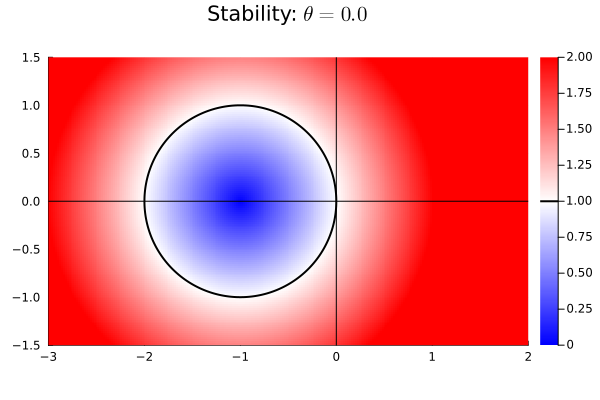

In [11]:
theta = .0
rk_theta(theta) = RKTable([theta], [1]')
rk_theta_endpoint(theta) = RKTable([0 0;1-theta theta], [1-theta theta])
table = rk_theta(theta)
plot_stability(z -> rk_stability(z, table), "\$\\theta = $theta\$")

# Heun's method and RK4

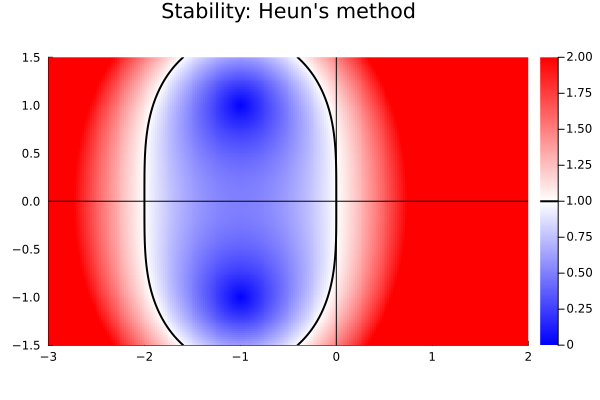

In [12]:
heun = RKTable([0 0; 1 0], [.5 .5])
plot_stability(z -> rk_stability(z, heun), "Heun's method")

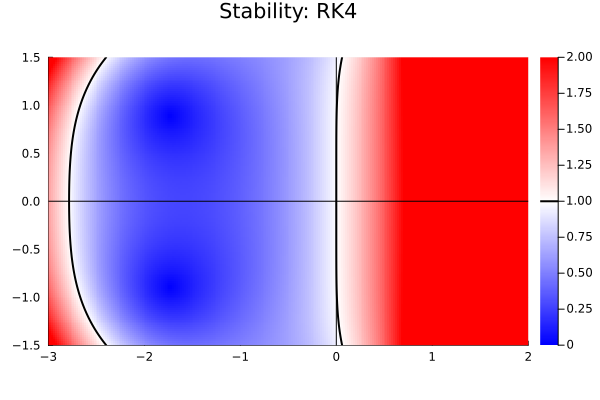

In [13]:
rk4 = RKTable([0 0 0 0; .5 0 0 0; 0 .5 0 0; 0 0 1 0],
[1 2 2 1] / 6)
plot_stability(z -> rk_stability(z, rk4), "RK4")

# An explicit RK solver

\begin{align}
Y_i &= u(t) + h \sum_j a_{ij} f(t+c_j h, Y_j) &
u(t+h) &= u(t) + h \sum_j b_j f(t+c_j h, Y_j)
\end{align}

In [14]:
function ode_rk_explicit(f, u0; tfinal=1, h=0.1, table=rk4)
    u = copy(u0)
    t = 0.
    n, s = length(u), length(table.c)
    fY = zeros(n, s)
    thist = [t]
    uhist = [u0]
    while t < tfinal
        tnext = min(t+h, tfinal)
        h = tnext - t
        for i in 1:s
            ti = t + h * table.c[i]
            Yi = u + h * sum(fY[:,1:i-1] * table.A[i,1:i-1], dims=2)
            fY[:,i] = f(ti, Yi)
        end
        u += h * fY * table.b[1,:]
        t = tnext
        push!(thist, t)
        push!(uhist, u)
    end
    thist, hcat(uhist...)
end

ode_rk_explicit (generic function with 1 method)

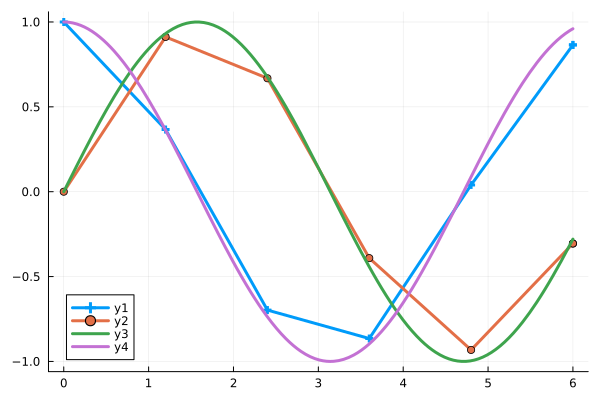

In [15]:
linear_oscillator(t, u) = [0 -1; 1 0] * u
thist, uhist = ode_rk_explicit(linear_oscillator, [1., 0], tfinal=6, h=1.2)
plot(thist, uhist', marker=:auto)
plot!([sin, cos])

# Measuring convergence and accuracy

In [16]:
function mms_error(h, f, u_exact; table=rk4)
    u0 = u_exact(0)
    thist, uhist = ode_rk_explicit(f, u0, tfinal=3, h=h, table=table)
    T = thist[end]
    uhist[:,end] - u_exact(T)
end

hs = .5 .^ (-3:8)
linear_oscillator_exact(t) = [cos(t), sin(t)]

linear_oscillator_exact (generic function with 1 method)

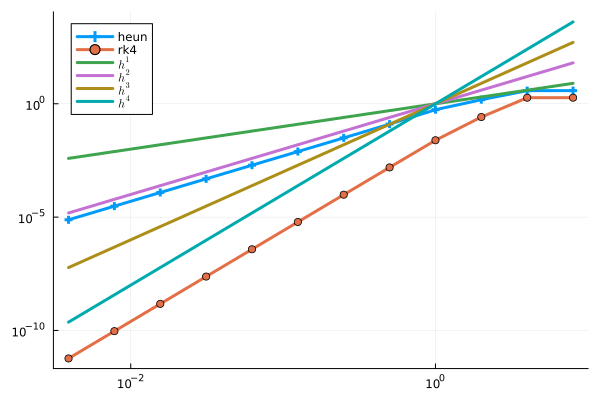

In [17]:
heun_errors = mms_error.(hs, linear_oscillator, linear_oscillator_exact, table=heun)
rk4_errors = mms_error.(hs, linear_oscillator, linear_oscillator_exact, table=rk4)
plot(hs, [norm.(heun_errors) norm.(rk4_errors)], label=["heun" "rk4"], marker=:auto)
plot!(hs, [hs hs.^2 hs.^3 hs.^4], label=["\$h^$p\$" for p in [1 2 3 4]], legend=:topleft, xscale=:log10, yscale=:log10)

# Work-precision (or accuracy vs cost)


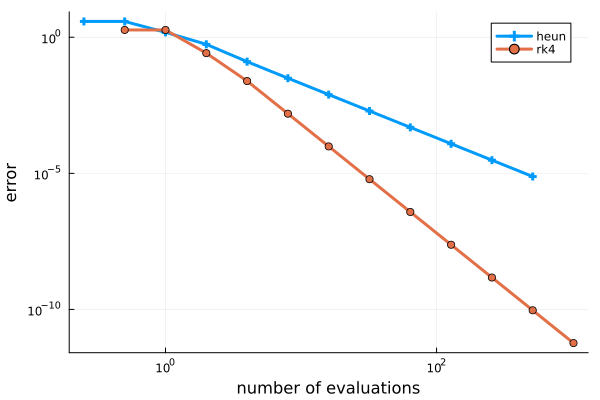

In [18]:
heun_nfeval = length(heun.c) ./ hs
rk4_nfeval = length(rk4.c) ./ hs
plot(heun_nfeval, norm.(heun_errors), marker=:auto, label="heun")
plot!(rk4_nfeval, norm.(rk4_errors), marker=:auto, label="rk4")
plot!(xscale=:log10, yscale=:log10, xlabel="number of evaluations", ylabel="error")

# Effective RK stability diagrams

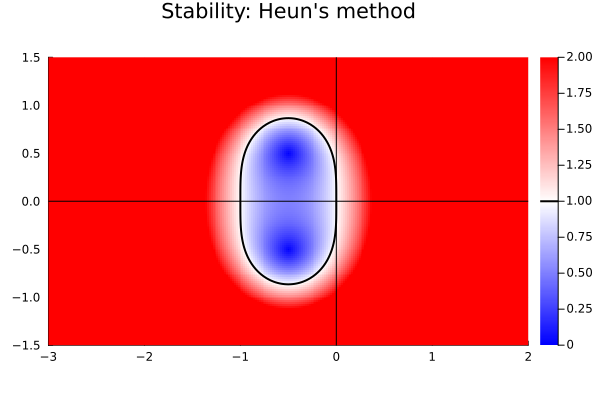

In [19]:
function rk_eff_stability(z, rk; brow=1)
    s = size(rk.b, 2)
    fsal = rk.b[1,:] ≈ rk.A[end,:]
    z = (s - fsal) * z
    1 + z * rk.b[brow,:]' * ((I - z*rk.A) \ ones(s))
end
plot_stability(z -> rk_eff_stability(z, heun), "Heun's method")

In [20]:
plot_stability(z -> rk_eff_stability(z, rk4), "RK4", xlims=(-2, 2), ylims=(-2, 2))

LoadError: MethodError: no method matching plot_stability(::var"#42#43", ::String; xlims::Tuple{Int64, Int64}, ylims::Tuple{Int64, Int64})
This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.

[0mClosest candidates are:
[0m  plot_stability(::Any, ::Any; xlim, ylim)[91m got unsupported keyword arguments "xlims", "ylims"[39m
[0m[90m   @[39m [35mMain[39m [90m[4mIn[2]:6[24m[39m


# Runge-Kutta order conditions

We consider the autonomous differential equation

$$ \dot u = f(u) . $$

Higher derivatives of the exact soultion can be computed using the chain rule, e.g.,

\begin{align*}
\ddot u(t) &= f'(u) \dot u = f'(u) f(u) \\
\dddot u(t) &= f''(u) f(u) f(u) + f'(u) f'(u) f(u) . \\
\end{align*}

Note that if $f(u)$ is linear, $f''(u) = 0$.
Meanwhile, the numerical solution is a function of the time step $h$,

$$\begin{split}
Y_i(h) &= u(0) + h \sum_j a_{ij} f(Y_j) \\
U(h) &= u(0) + h \sum_j b_j f(Y_j).
\end{split}$$

We will take the limit $h\to 0$ and equate derivatives of the numerical solution.  First we differentiate the stage equations,

\begin{split}
Y_i(0) &= u(0) \\
\dot Y_i(0) &= \sum_j a_{ij} f(Y_j) \\
\ddot Y_i(0) &= 2 \sum_j a_{ij} \dot f(Y_j) \\
&= 2 \sum_j a_{ij} f'(Y_j) \dot Y_j \\
&= 2\sum_{j,k} a_{ij} a_{jk} f'(Y_j) f(Y_k) \\
\dddot Y_i(0) &= 3 \sum_j a_{ij} \ddot f (Y_j) \\
&= 3 \sum_j a_{ij} \Big( \sum_k f''(Y_j) \dot Y_j \dot Y_k + f'(Y_j) \ddot Y_j \Big) \\
&= 3 \sum_{j,k,\ell} a_{ij} a_{jk} \Big( a_{j\ell} f''(Y_j) f(Y_k) f(Y_\ell) + 2 a_{k\ell} f'(Y_j) f'(Y_k) f(Y_\ell)  \Big)
\end{split}

where we have used Liebnitz's formula for the $m$th derivative,
$$ (h \phi(h))^{(m)}|_{h=0} = m \phi^{(m-1)}(0) .$$
Similar formulas apply for $\dot U(0)$, $\ddot U(0)$, and $\dddot U(0)$, with $b_j$ in place of $a_{ij}$.

# Order conditions are nonlinear algebraic equations

Equating terms $\dot u(0) = \dot U(0)$ yields
$$ \sum_j b_j = 1, $$
equating $\ddot u(0) = \ddot U(0)$ yields
$$ 2 \sum_{j,k} b_j a_{jk} = 1 , $$
and equating $\dddot u(0) = \dddot U(0)$ yields the two equations
\begin{split}
  3\sum_{j,k,\ell} b_j a_{jk} a_{j\ell} &= 1 \\
  6 \sum_{j,k,\ell} b_j a_{jk} a_{k\ell} &= 1 .
\end{split}

# Observations

* These are systems of nonlinear equations for the coefficients $a_{ij}$ and $b_j$.  There is no guarantee that they have solutions.
* The number of equations grows rapidly as the order increases.

|  | $u^{(1)}$       | $u^{(2)}$   |  $u^{(3)}$ | $u^{(4)}$ | $u^{(5)}$ | $u^{(6)}$ | $u^{(7)}$ | $u^{(8)}$ | $u^{(9)}$ | $u^{(10)}$ |
| ----------- |---|---|---|---|---|----|----|-----|-----|-----|
| # terms     | 1 | 1 | 2 | 4 | 9 | 20 | 48 | 115 | 286 | 719 |
| cumulative | 1 | 2 | 4 | 8 | 17 | 37 | 85 | 200 | 486 | 1205 |

* Usually the number of order conditions does not exactly match the number of free parameters, meaning that the remaining parameters can be optimized (usually numerically) for different purposes, such as to minimize the leading error terms or to maximize stability in certain regions of the complex plane.  Finding globally optimal solutions can be extremely demanding.

* Rooted trees provide a convenient notation

![Trees and elementary differentials up to order 5. From Hairer, Nørsett, and Wanner.](../img/rktrees.png)

# Theorem (from Hairer, Nørsett, and Wanner)

A Runge-Kutta method is of order $p$ if and only if
$$ \gamma(\mathcal t) \sum_{j} b_j \Phi_j(t) = 1 $$
for all trees $t$ of order $\le p$.

For a linear autonomous equation
$$ \dot u = A u $$
we only need one additional order condition per order of accuracy because $f'' = 0$.
These conditions can also be derived by equating derivatives of the stability function $R(z)$ with the exponential $e^z$.
For a linear non-autonomous equation
$$ \dot u = A(t) u + g(t) $$
or more generally, an autonomous system with quadratic right hand side,
$$ \dot u = B (u \otimes u) + A u + C $$
where $B$ is a rank 3 tensor, we have $f''' = 0$, thus limiting the number of order conditions.

# Embedded error estimation

It is often possible to design Runge-Kutta methods with multiple completion orders, say of order $p$ and $p-1$.

$$\left[ \begin{array}{c|c} c & A \\ \hline & b^T  \\ & \tilde b^T \end{array} \right] . $$

The classical RK4 does not come with an embedded method, but most subsequent RK methods do. The [Bogacki-Shampine method](https://en.wikipedia.org/wiki/Bogacki%E2%80%93Shampine_method) is one such method.

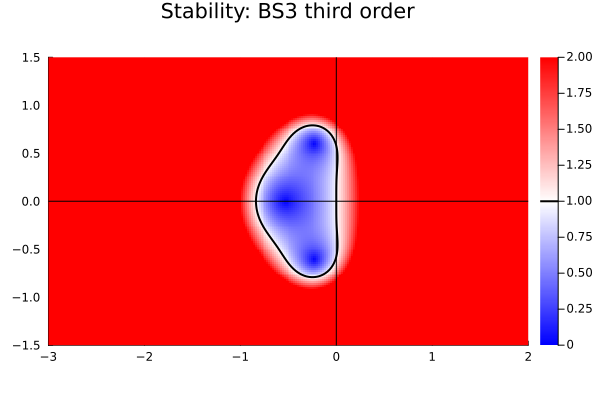

In [21]:
bs3 = RKTable([0 0 0 0; 1/2 0 0 0; 0 3/4 0 0; 2/9 1/3 4/9 0],
    [2/9 1/3 4/9 0; 7/24 1/4 1/3 1/8])
plot_stability(z -> rk_eff_stability(z, bs3), "BS3 third order")

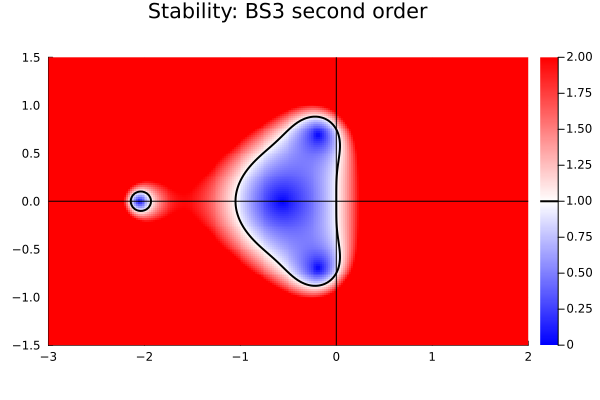

In [22]:
plot_stability(z -> rk_eff_stability(z, bs3, brow=2), "BS3 second order")

# Properties

In [23]:
display(bs3.A)
display(bs3.b)

4×4 Matrix{Float64}:
 0.0       0.0       0.0       0.0
 0.5       0.0       0.0       0.0
 0.0       0.75      0.0       0.0
 0.222222  0.333333  0.444444  0.0

2×4 Matrix{Float64}:
 0.222222  0.333333  0.444444  0.0
 0.291667  0.25      0.333333  0.125

* First same as last (FSAL): the completion formula $b$ is the same as the last row of $A$.
  * Stage can be reused as first stage of the next time step. So this 4-stage method has a cost equal to a 3-stage method.
* [Fehlberg](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta%E2%80%93Fehlberg_method), a 6-stage, 5th order method for which the 4th order embedded formula has been optimized for accuracy.
* [Dormand-Prince](https://en.wikipedia.org/wiki/Dormand%E2%80%93Prince_method), a 7-stage, 5th order method with the FSAL property, with the 5th order completion formula optimized for accuracy.

# Adaptive step size control

Given a completion formula $b^T$ of order $p$ and $\tilde b^T$ of order $p-1$, an estimate of the local truncation error (on this step) is given by
$$ e_{\text{loc}}(h) = \lVert h (b - \tilde b)^T f(Y) \rVert \in O(h^p) . $$
Given a tolerance $\epsilon$, we would like to find $h_*$ such that
$$ e_{\text{loc}}(h_*) < \epsilon . $$
If $$e_{\text{loc}}(h) = c h^p$$ for some constant $c$, then
$$ c h_*^p < \epsilon $$
implies
$$ h_* < \left( \frac{\epsilon}{c} \right)^{1/p} . $$
Given the estimate with the current $h$,
$$ c = e_{\text{loc}}(h) / h^p $$
we conclude
$$ \frac{h_*}{h} < \left( \frac{\epsilon}{e_{\text{loc}}(h)} \right)^{1/p} . $$

## Notes
* Usually a "safety factor" less than 1 is included so the predicted error is less than the threshold to reject a time step.
* We have used an absolute tolerance above.  If the values of solution variables vary greatly in time, a relative tolerance $e_{\text{loc}}(h) / \lVert u(t) \rVert$ or a combination thereof is desirable.
* There is a debate about whether one should optimize the rate at which error is accumulated with respect to work (estimate above) or with respect to simulated time (as above, but with error behaving as $O(h^{p-1})$).  For problems with a range of time scales at different periods, this is usually done with respect to work.
* Global error control is an active research area.

# Diagonally Implicit Runge-Kutta methods

<div class="floatright">

$$ \left[ \begin{array}{c|c} c & A \\ \hline & b^T \end{array} \right] = \left[ \begin{array}{c|cc}
c_0 & a_{00} & 0 \\
c_1 & a_{10} & a_{11} \\
\hline
& b_0 & b_1
\end{array} \right] $$
</div>

In [24]:
# From Hairer and Wanner Table 6.5 L-stable SDIRK
dirk4 = RKTable([1/4 0 0 0 0; 1/2 1/4 0 0 0; 17/50 -1/25 1/4 0 0; 371/1360 -137/2720 15/544 1/4 0; 25/24 -49/48 125/16 -85/12 1/4],
    [24/24 -49/48 125/16 -85/12 1/4; 59/48 -17/96 225/32 -85/12 0]);
#dirk4.A

In [29]:
function plot_stability(Rz, title; xlims=(-3, 3), ylims=(-2, 2))
    x = LinRange(xlims[1], xlims[2], 100)
    y = LinRange(ylims[1], ylims[2], 100)
    heatmap(x, y, (x, y) -> abs(Rz(x + 1im*y)), c=:bwr, clims=(0, 2), aspect_ratio=:equal, title=title)
end

plot_stability (generic function with 1 method)

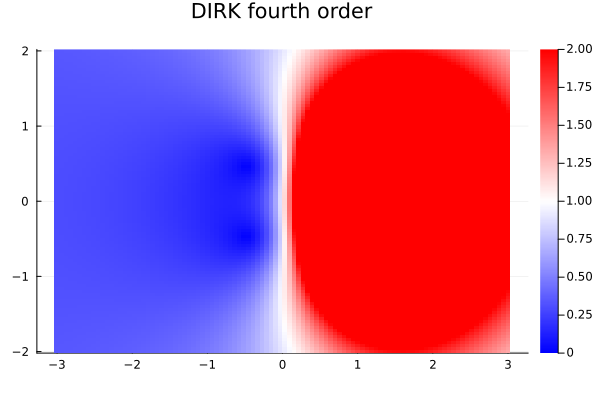

In [30]:
plot_stability(z -> rk_eff_stability(z, dirk4, brow=1), "DIRK fourth order")

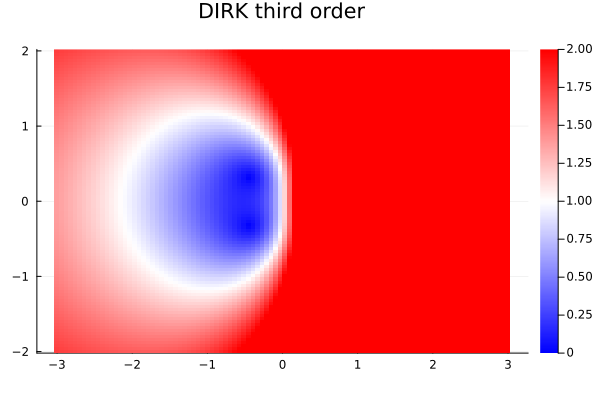

In [31]:
plot_stability(z -> rk_eff_stability(z, dirk4, brow=2), "DIRK third order")

# Fully implicit Runge-Kutta methods

<div class="floatright">

$$ \left[ \begin{array}{c|c} c & A \\ \hline & b^T \end{array} \right] = \left[ \begin{array}{c|cc}
c_0 & a_{00} & a_{01} \\
c_1 & a_{10} & a_{11} \\
\hline
& b_0 & b_1
\end{array} \right] $$
</div>

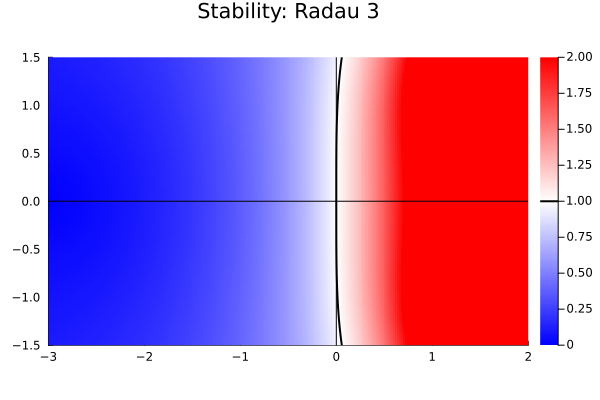

In [27]:
radau3 = RKTable([5/12 -1/12; 3/4 1/4], [3/4 1/4])
plot_stability(z -> rk_eff_stability(z, radau3), "Radau 3")

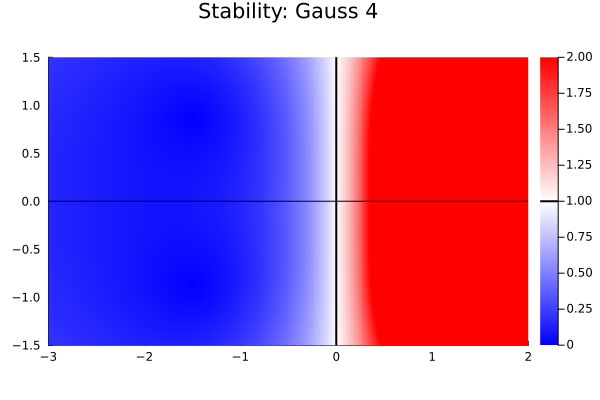

In [28]:
gauss4 = RKTable([1/4 1/4-sqrt(3)/6; 1/4+sqrt(3)/6 1/4],
    [1/2 1/2])
plot_stability(z -> rk_eff_stability(z, gauss4), "Gauss 4")

# Explore benchmarks: https://benchmarks.sciml.ai/

* Find at least one interesting figure
* You can work in groups

## Report-out/discuss next class
* Explain something about the figure
* Ask a question
